### Video playback

In [2]:
## conda env: stereo_vision
import os
import cv2
import numpy as np
import pyzed.sl as sl
import matplotlib.pyplot as plt

In [4]:
# load coordinates of keypoints

input_folder = "saved_coords"
input_file_name = "straight_walk.mp4_ankle_coords.npy"

ankle_coords = np.load(os.path.join(input_folder, input_file_name))
ankle_coords.shape

(393, 17, 2)

In [5]:
zed_ankle_depths = []

# Create a ZED camera object
zed = sl.Camera()

# Set SVO path for playback
input_path = "./stereo_videos/straight_walk.svo2"
input_type = sl.InputType()
input_type.set_from_svo_file(input_path)  # Set init parameter to run from the .svo
init_parameters = sl.InitParameters(input_t=input_type, svo_real_time_mode=False)

init_parameters.depth_mode = sl.DEPTH_MODE.ULTRA
init_parameters.coordinate_units = sl.UNIT.CENTIMETER  # CENTIMETER, METER, MILLIMETER
init_parameters.depth_stabilization = 100


# Open the ZED
zed = sl.Camera()
err = zed.open(init_parameters)

svo_depth = sl.Mat()
svo_image = sl.Mat()

while zed.grab() == sl.ERROR_CODE.SUCCESS:

    # Get frame count
    svo_position = zed.get_svo_position()

    # get color image and depth map
    zed.retrieve_measure(svo_depth, sl.MEASURE.DEPTH)
    zed.retrieve_image(svo_image, sl.VIEW.LEFT)
    img = svo_image.get_data()
    depth_map = svo_depth.get_data()

    ## ankle coords
    left_ankle_x = int(ankle_coords[svo_position, 15, 0])
    left_ankle_y = int(ankle_coords[svo_position, 15, 1])

    right_ankle_x = int(ankle_coords[svo_position, 16, 0])
    right_ankle_y = int(ankle_coords[svo_position, 16, 1])

    depth_left_ankle = depth_map[left_ankle_x, left_ankle_y]
    depth_right_ankle = depth_map[right_ankle_x, right_ankle_y]

    zed_ankle_depths.append(np.array([depth_left_ankle, depth_right_ankle]))

    ## put markers on image for verification
    cv2.circle(img, (left_ankle_x, left_ankle_y), 5, (0, 0, 255), 3)

    ## show DEPTH
    # cv2.imshow("View", svo_depth.get_data())

    ## show frame
    cv2.imshow("vid", img)

    if cv2.waitKey(25) & 0xFF == ord("q"):
        break

zed.close()
cv2.destroyAllWindows()

zed_ankle_depths = np.array(zed_ankle_depths)
zed_ankle_depths.shape

(392, 2)

'straight_walk'

In [9]:
out_folder = "saved_keypoint_depth"
out_file_name = input_file_name.split(".mp4")[0]
np.save(
    f"{os.path.join(out_folder,out_file_name)}_ankle_depth_cm.npy", zed_ankle_depths
)

In [39]:
zed_ankle_depths[100:300].shape

(200, 2)

In [24]:
t = zed_ankle_depths[100:300] / 60
t.shape

(200, 2)

In [56]:
t = (
    np.linspace(0, len(zed_ankle_depths[100:300]) - 1, len(zed_ankle_depths[100:300]))
    / 60
)


t.shape


# t

(200,)

Text(0.5, 1.0, '[cm]')

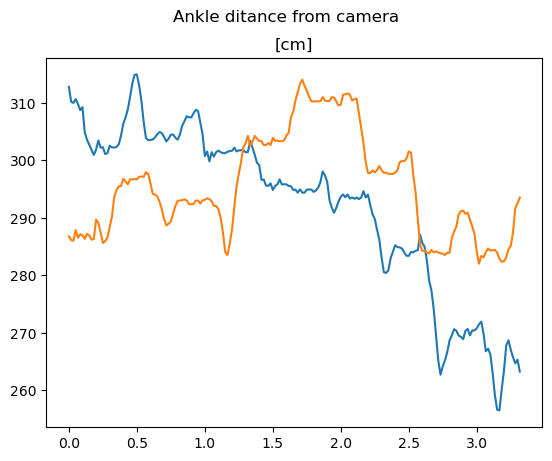

In [57]:
t = (
    np.linspace(0, len(zed_ankle_depths[100:300]) - 1, len(zed_ankle_depths[100:300]))
    / 60
)


plt.figure()


plt.plot(t, zed_ankle_depths[100:300])


plt.suptitle("Ankle ditance from camera")


plt.title("[cm]")


# plt.plot(zed_ankle_depths)

In [34]:
ankle_coords[0, 15, 0], ankle_coords[0, 15][1]

(285.0, 650.0)

In [38]:
svo_image.get_data()[int(ankle_coords[0, 15, 0]), int(ankle_coords[0, 15, 1])]

10282.033

In [31]:
svo_image.get_data()[0, 0]

nan

In [18]:
num_frames = zed.get_svo_number_of_frames()

In [ ]:
for i in range(0, num_frames):
    print(ankle_coords[i])